# Data Statistics

In this notebook, i try to show some statistic about finance data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [4]:
# lets read all csv files to get one big chunk
df_main = pd.DataFrame()
for file in os.listdir("../input/raw_data"):
    df = pd.read_csv("../input/raw_data/"+file)
    
    # insert percent change column into main dataframe
    percentage = df.adjusted_close.pct_change(periods=1)
    percentage.iloc[0] = 0.0
    df['percent_change'] = percentage
    
    # calculate change of values between days
    shifted = df.adjusted_close.shift(periods=1)
    shifted[0] = 0.0
    diff = df.adjusted_close - shifted
    diff[0] = 0.0
    df['change'] = diff  
    
    
    
    df_main = pd.concat([df_main,df]) 
df_main = df_main.reset_index(drop=True)

In [5]:
df.head()

,date,open,high,low,close,volume,adjusted_close,percent_change,change
0,2000-01-03,31.00,31.00,29.86,30.12,212900.0,30.12,0.000000,0.00
1,2000-01-04,29.69,29.81,29.03,29.22,177200.0,29.22,-0.029880,-0.90
2,2000-01-05,29.34,29.34,28.72,28.86,124600.0,28.86,-0.012320,-0.36
3,2000-01-06,29.05,29.41,29.00,29.19,135800.0,29.19,0.011435,0.33
4,2000-01-07,29.50,30.56,29.50,30.56,69400.0,30.56,0.046934,1.37


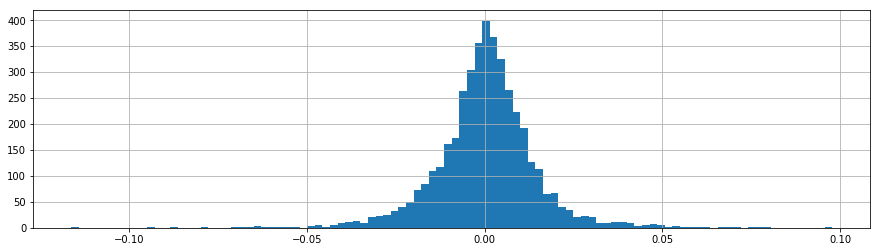

In [6]:
df.percent_change.hist(bins=100, figsize=(15,4)) # as expected it is a normal distribution

In [7]:
# i wanna create some helper function
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

def split_count(series, threshold):
    return (series.loc[series < -threshold].count(),
                series.loc[np.logical_and(series <= threshold,series >= -threshold)].count(),
                series.loc[series > threshold].count())

def split(series, threshold):
    return (series.loc[series < -threshold],
                series.loc[np.logical_and(series <= threshold,series >= -threshold)],
                series.loc[series > threshold])

def normalize_1_1(series):
    norm_0_1 = (series - series.min()) / (series.max()- series.min()) #normalized btw 0 to 1
    return norm_0_1*2 - 1  #normalized btw -1 to 1

def normalize_mean_var(series):
    return (series - series.mean()) / series.std()

In [8]:
# below shows the distribution of the percent change
split_count(df.percent_change, 0.0)

(2007, 70, 2209)

In [9]:
# when we have too little values like 0.003 , 0.004, tanh function does not expand data so well.
# so i want to make values bigger. so lets drop percent and multiply with 100.
df['percent_change_mul_100'] = df.percent_change * 100
# now i can apply tanh function to spread values between -1 to 1.
df['percent_change_mul_100_tanh'] = df.percent_change_mul_100.apply(np.tanh)

In [10]:
df.head()

,date,open,high,low,close,volume,adjusted_close,percent_change,change,percent_change_mul_100,percent_change_mul_100_tanh
0,2000-01-03,31.00,31.00,29.86,30.12,212900.0,30.12,0.000000,0.00,0.000000,0.000000
1,2000-01-04,29.69,29.81,29.03,29.22,177200.0,29.22,-0.029880,-0.90,-2.988048,-0.994935
2,2000-01-05,29.34,29.34,28.72,28.86,124600.0,28.86,-0.012320,-0.36,-1.232033,-0.843168
3,2000-01-06,29.05,29.41,29.00,29.19,135800.0,29.19,0.011435,0.33,1.143451,0.815573
4,2000-01-07,29.50,30.56,29.50,30.56,69400.0,30.56,0.046934,1.37,4.693388,0.999832


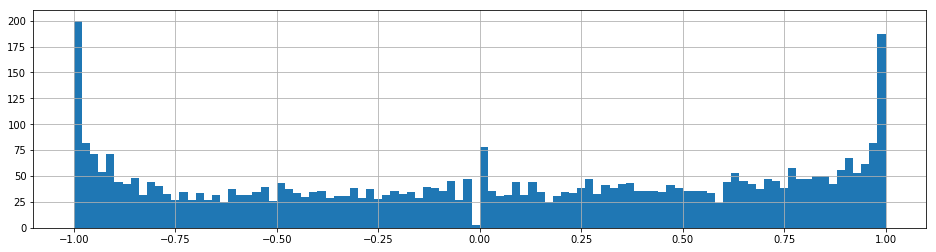

In [11]:
df.percent_change_mul_100_tanh.hist(bins=100, figsize=(16,4))

In [12]:
split_count(df.percent_change_mul_100_tanh, 0.38)

(1384, 1362, 1540)

In [13]:
# with the help of split function, i split values in 3 different case.
below,same,above = split(df.percent_change_mul_100_tanh, 0.38)

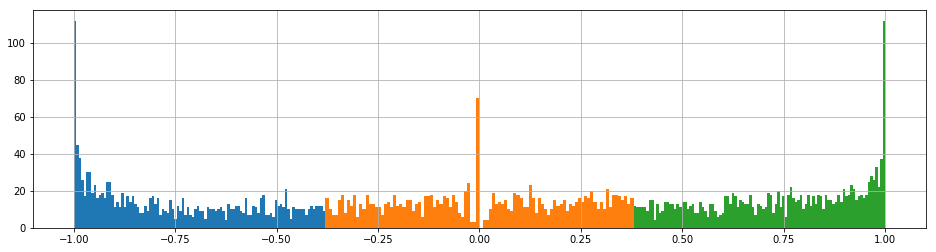

In [14]:
# when i plot their histogram. i can see what i want.

below.hist(bins=100, figsize=(16,4))
same.hist(bins=100, figsize=(16,4))
above.hist(bins=100, figsize=(16,4))

# Variance minimization

**Note**
Up to now, i normalized the data and get rougly 3 label from it.
From precision point of view, i want to create a function which split whole data into 3 chunks while minimizing sum of variances.

In [15]:
var_list = []
for i in range(100):
    ratio = i/100
    below,same,above = split(df.percent_change_mul_100_tanh, ratio) 
    var_list.append(below.var() + same.var() + above.var())
np.argmin(var_list)/100 # argmin of variance list

0.38

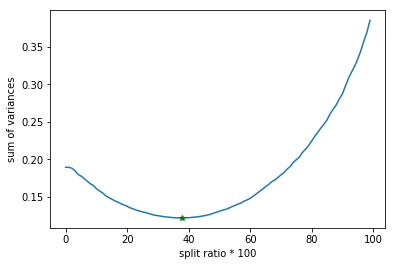

In [16]:
plt.plot(var_list)
plt.plot(np.argmin(var_list),np.min(var_list),'g*')
plt.ylabel("sum of variances")
plt.xlabel("split ratio * 100")

As seen above, i will chose split ratio as **0.38** and use the normalized data as **"np.tanh(percent_change*100)"**